# Bank Term Deposit Subscription — Prediction & Call-Targeting Pipeline

**Goal.** Predict which clients contacted in a bank telemarketing campaign are likely to
subscribe to a term deposit, and use that prediction to reduce the number of calls an
agent has to make while still reaching most of the actual subscribers.

**Data.** The UCI Bank Marketing dataset (`bank-full.csv`), ~45k rows, target `y`
(subscribed: yes/no), heavily imbalanced (~11.7% positive).

**Approach, in short:**
1. EDA to understand the target imbalance and how features relate to subscription.
2. Feature engineering: day-of-month bucketing, campaign-count bucketing, encoding of
   categoricals, and a Yeo-Johnson transform for skewed numeric features.
3. **Two-stage modelling.** Rather than one model using every feature (including
   in-campaign features that are only known once you've already decided to call
   someone), we train two separate models:
   - **Stage 1 ("pre-call")**: uses only static client attributes known *before* any
     contact decision is made (age, job, balance, etc.).
   - **Stage 2 ("campaign")**: adds in campaign-context features (contact channel,
     month, day-of-month bucket, previous-campaign outcome) to refine the score for
     clients Stage 1 flags as promising.
   - Stage 1's score is used only to *select* which clients proceed to Stage 2; the
     final `final_score` used to decide who to call (and how/when, see the campaign
     simulation section) is Stage 2's own probability.
4. A precision/recall threshold is chosen on a held-out **validation** set, then
   applied once to the untouched **test** set to report business impact (calls saved,
   time saved, subscribers still reached).




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

## 1. Data Loading & Exploratory Data Analysis

Load the raw CSV, check its shape/types/duplicates/missing values, then look at how the
target and each feature are distributed, to guide the feature-engineering choices in
Section 2.

In [2]:
#EDA
df = pd.read_csv('bank-full.csv', delimiter=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
#null check
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [4]:
df.describe()


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Text(0.5, 1.0, 'Distribution of Target Variable (y)')

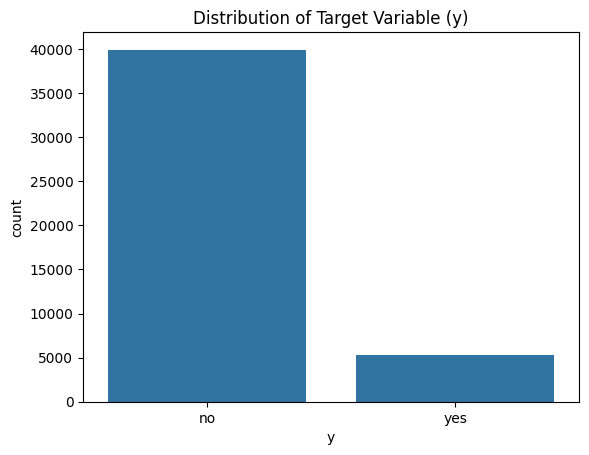

In [7]:
sns.countplot(x='y', data=df)
plt.title('Distribution of Target Variable (y)')

In [8]:
df["y"]=df["y"].map({'yes':1,'no':0})
df["y"].value_counts(normalize=True)

y
0    0.883015
1    0.116985
Name: proportion, dtype: float64

#indicates imbalance with 88.3 % belonging to the yes "NO" class asnd only 11.7 % belonging to the yes class

In [9]:
def plot_facet_grid(feature, bins):
    g = sns.FacetGrid(df, col='y', height=5, aspect=1.2)
    g.map(sns.histplot, feature, bins=bins, color='#3498db', kde=False)
    g.set_titles(col_template='Target = {col_name}')
    g.set_axis_labels(feature, "Count")
    g.fig.suptitle(f"{feature} Distribution by Term Deposit Subscription", y=1.05)
    plt.tight_layout()
    plt.show()

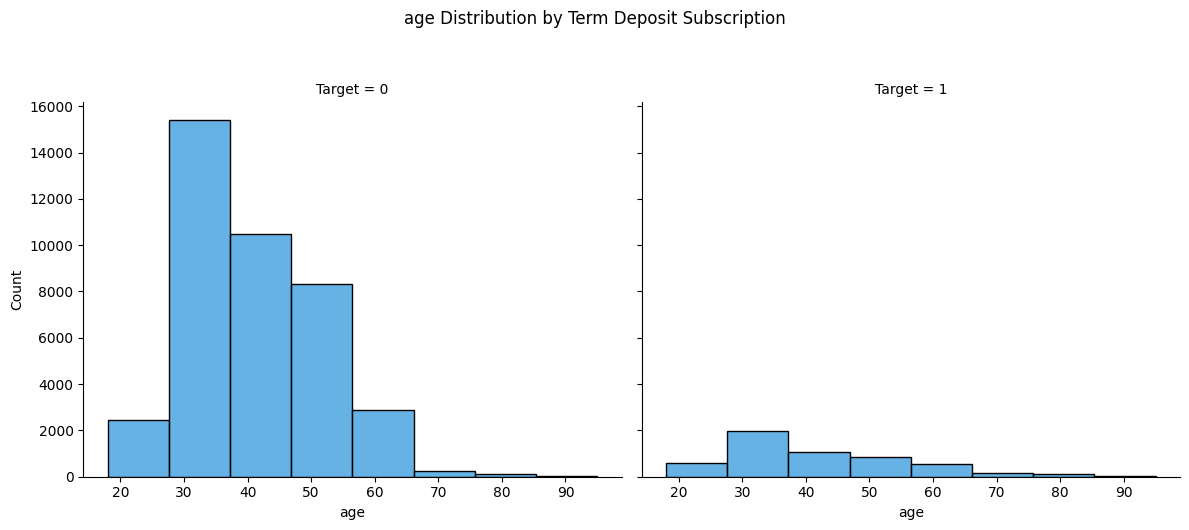

In [10]:
plot_facet_grid('age',8)

In [11]:
def plot_TargetbyCat(feature, bar_height=0.5, height_per_row=0.6):
    job_counts_abs = pd.crosstab(df[feature], df['y']).sort_values(by=1, ascending=False)
    jobs = job_counts_abs.index
    counts_no = job_counts_abs[0]
    counts_yes = job_counts_abs[1]

    # Dynamically set height based on number of categories
    dynamic_height = max(4, len(jobs) * height_per_row)
    fig, ax = plt.subplots(figsize=(12, dynamic_height))

    bar_min_width = 200

    bar_no = ax.barh(jobs, counts_no, color='#5DADE2', label='No (0)', height=bar_height)
    bar_yes = ax.barh(jobs, counts_yes, left=counts_no, color='#1ABC9C', label='Yes (1)', height=bar_height)

    for i, (no, yes) in enumerate(zip(counts_no, counts_yes)):
        total = no + yes
        yes_pct = f'{yes / total:.1%}'
        no_pct = f'{no / total:.1%}'

        ax.text(no / 2, i, no_pct, va='center', ha='center', color='white', fontsize=9)

        if yes > bar_min_width:
            ax.text(no + yes / 2, i, yes_pct, va='center', ha='center', color='white', fontsize=9)
        else:
            ax.text(no + yes + 50, i, yes_pct, va='center', ha='left', color='black', fontsize=9)

    ax.set_xlabel("Number of Records")
    ax.set_title(f"Term Deposit Subscriptions by {feature} (Absolute Count & Proportion)")
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

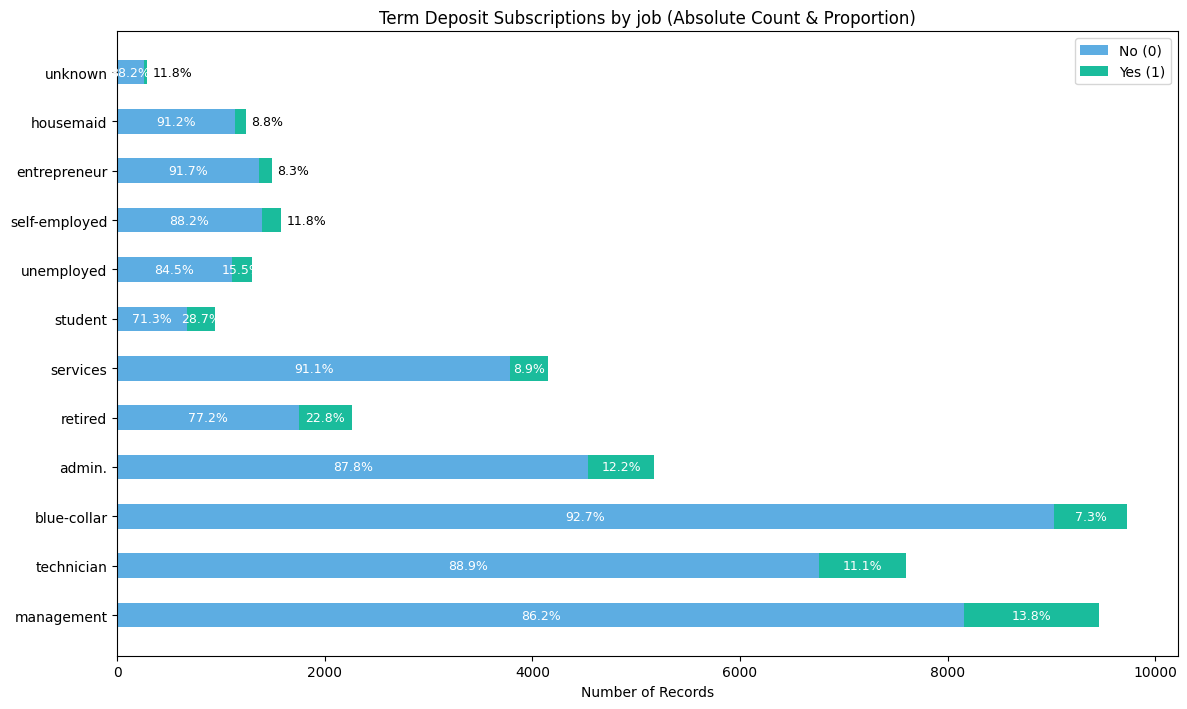

In [12]:
plot_TargetbyCat('job')

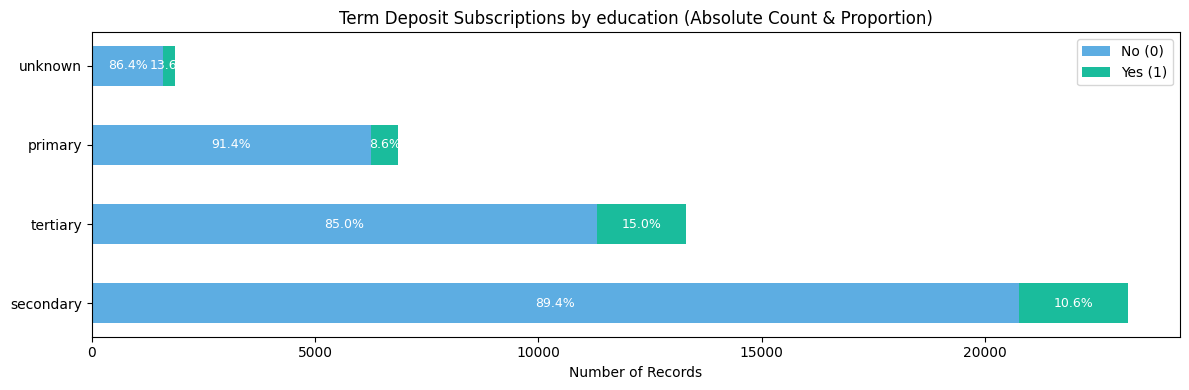

In [13]:
plot_TargetbyCat('education')

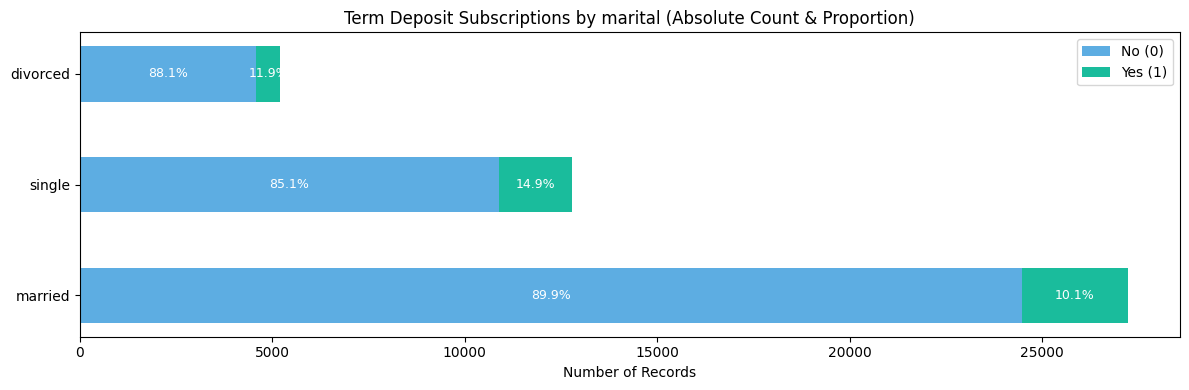

In [14]:
plot_TargetbyCat('marital')

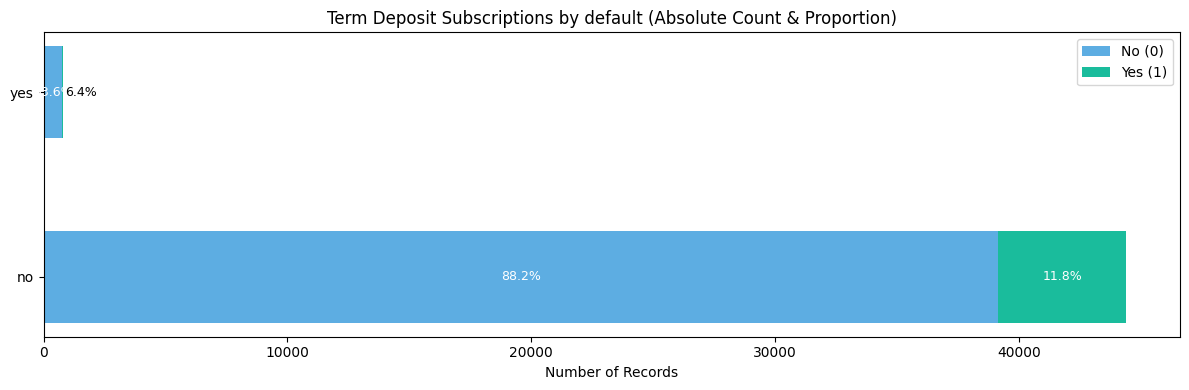

In [15]:
#people with default are less likely to subscribe to term deposit than those without default
plot_TargetbyCat('default')

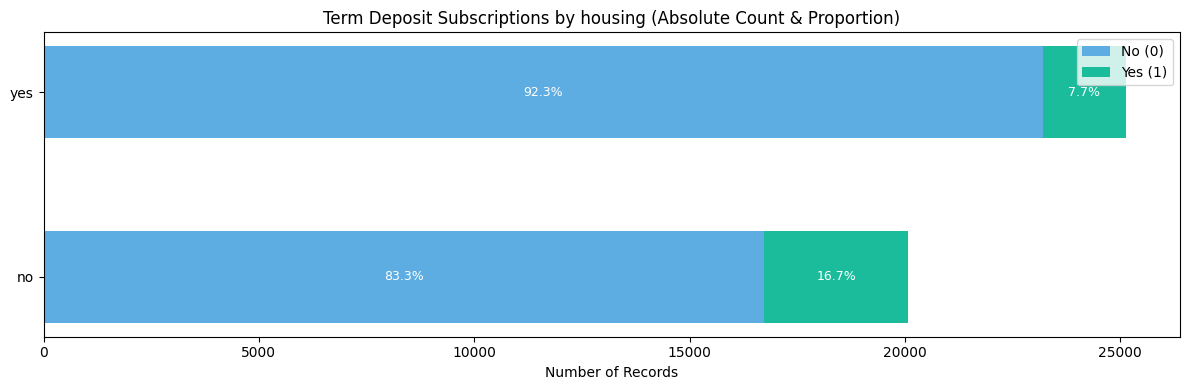

In [16]:
#people with house loan are less likely to subscribe to term deposit than those without house loan
plot_TargetbyCat('housing')

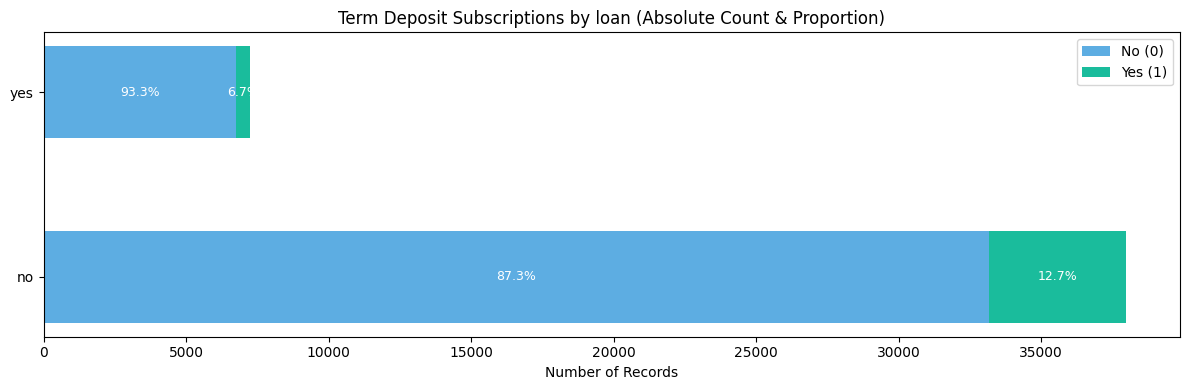

In [17]:
plot_TargetbyCat('loan')

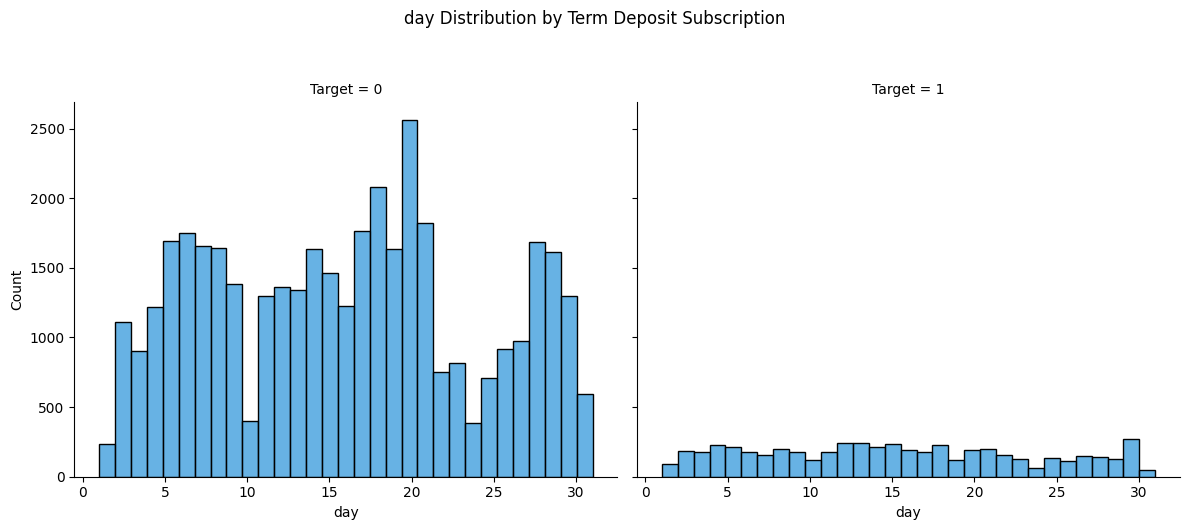

In [18]:
plot_facet_grid("day",31)

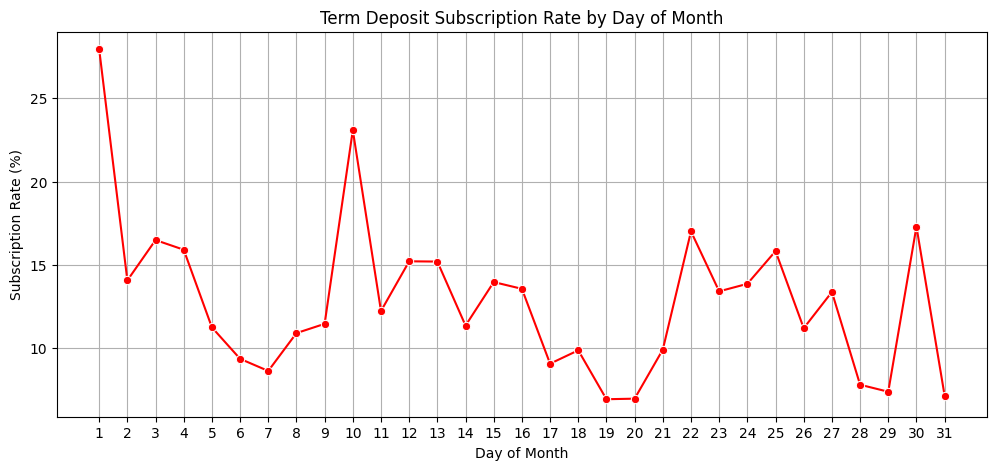

In [19]:
conversion_by_day = df.groupby('day')['y'].mean() * 100

plt.figure(figsize=(12, 5))
sns.lineplot(x=conversion_by_day.index, y=conversion_by_day.values, marker='o', color='RED')
plt.title("Term Deposit Subscription Rate by Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Subscription Rate (%)")
plt.grid(True)
plt.xticks(range(1, 32))
plt.show()

Here we can observe spikes in the begining and end of the month in deposit subscription deposit rate. Thereofore, the days at the beginning and end are important. 

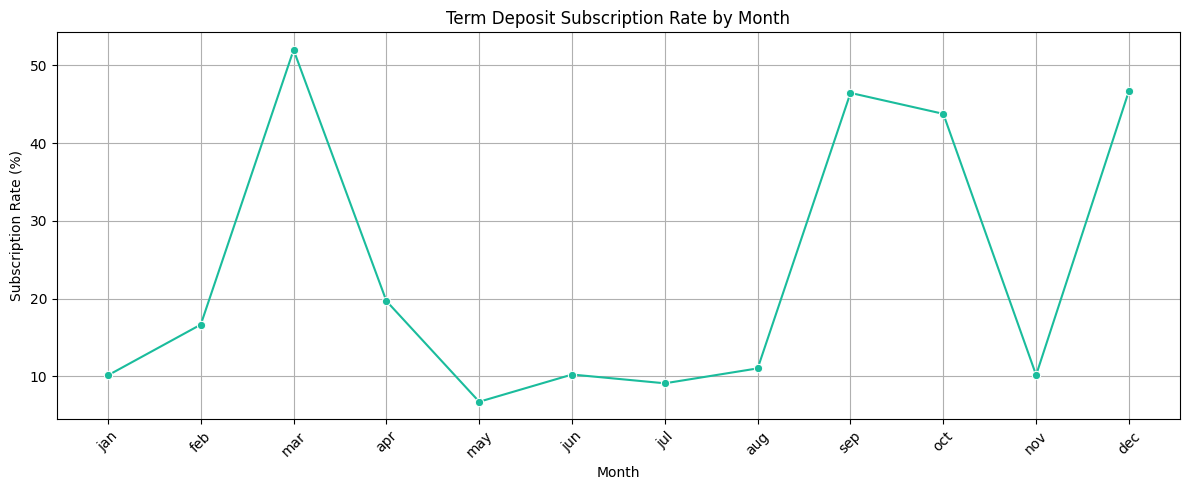

In [20]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
df['month'] = df['month'].str.lower()
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)
conversion_by_month = df.groupby('month',observed=True)['y'].mean() * 100

plt.figure(figsize=(12, 5))
sns.lineplot(x=conversion_by_month.index, y=conversion_by_month.values, marker='o', color='#1ABC9C')
plt.title("Term Deposit Subscription Rate by Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate (%)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
def plot_callDurationDistByFeature(feature):

    plt.figure(figsize=(15, 6))
    ax = sns.boxplot(x=feature, y='duration', hue='y', data=df, palette=['RED', 'BLUE'])
    plt.title(f"Call Duration Distribution by {feature} and Subscription Outcome")
    plt.xlabel("Day of Month" if feature=='day' else feature)
    plt.ylabel("Call Duration (seconds)")
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['No', 'Yes'], title='Subscribed')
    
    plt.tight_layout()
    plt.show()

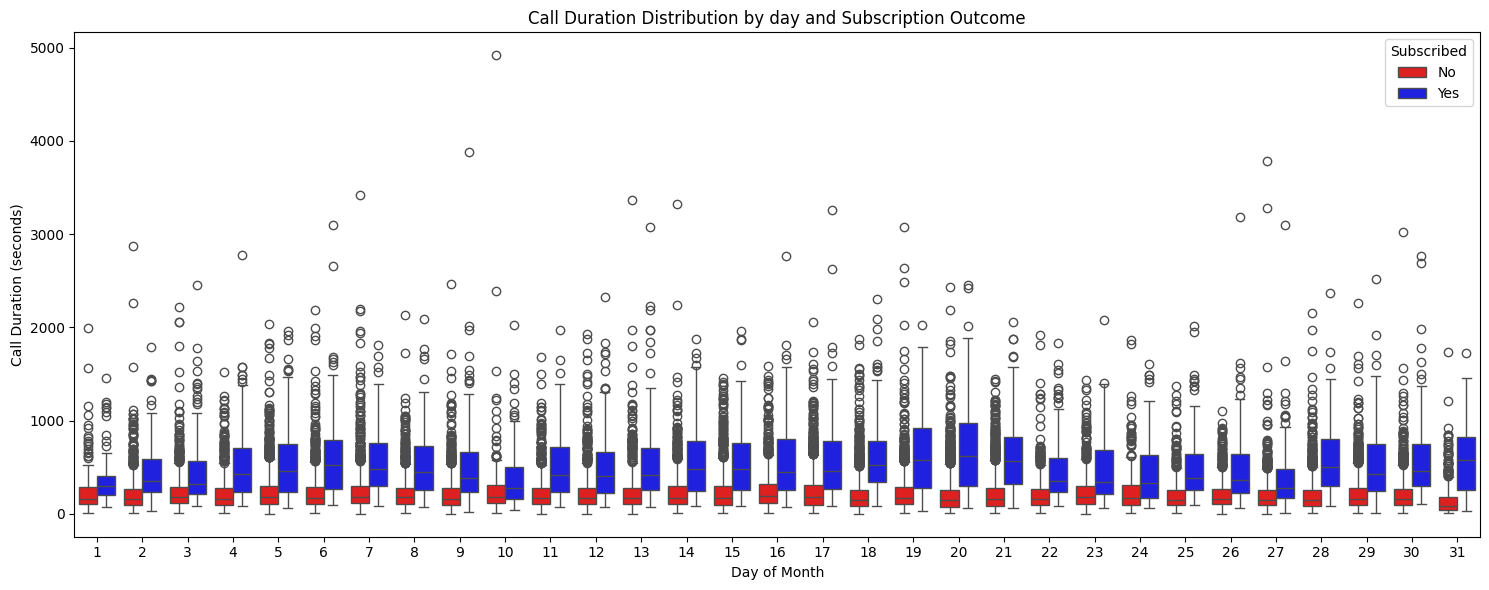

In [22]:
plot_callDurationDistByFeature('day')

OBSERVATIONS

1.Right skewed distribution amongst non subscribers
2.The duration of calls is higher for subscribers
3.Prescence of a significant number of outliers in the non subscriber segment, possibly indicates intrested people who have not subscribed.
4.Across all days, the call duration is higher for the subscibers.

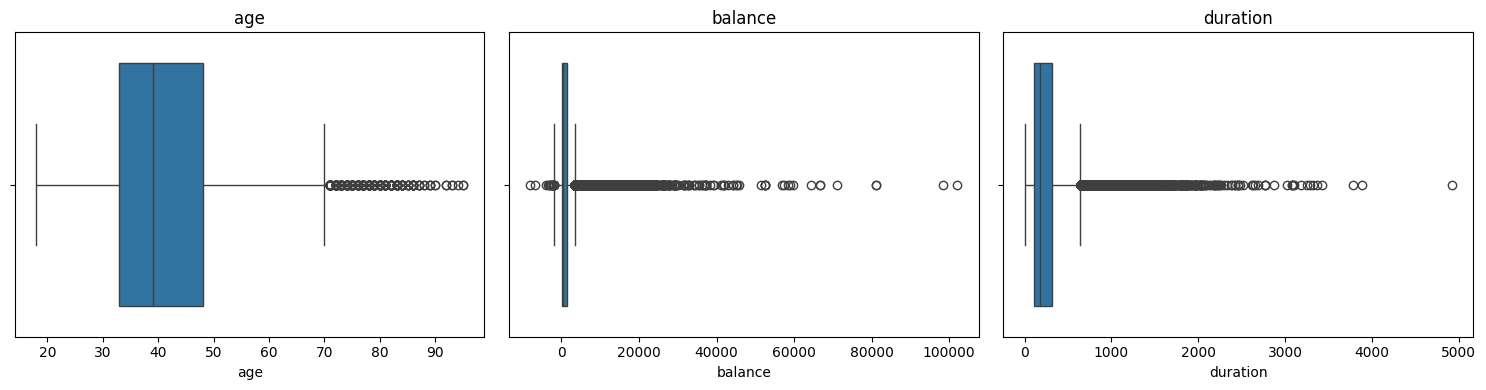

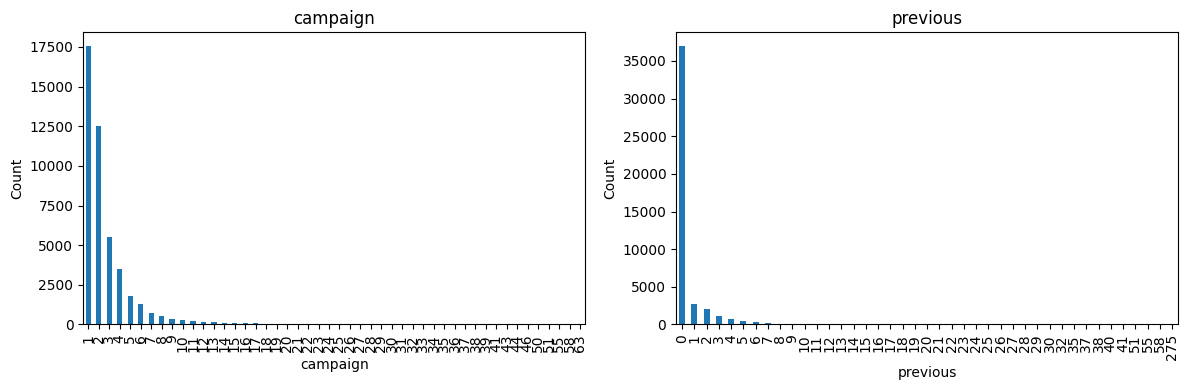

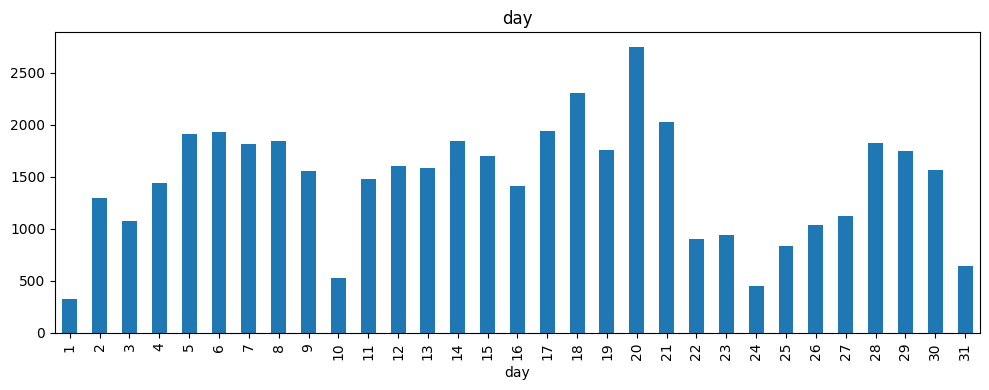

Never previously contacted: 36954 (81.7%)


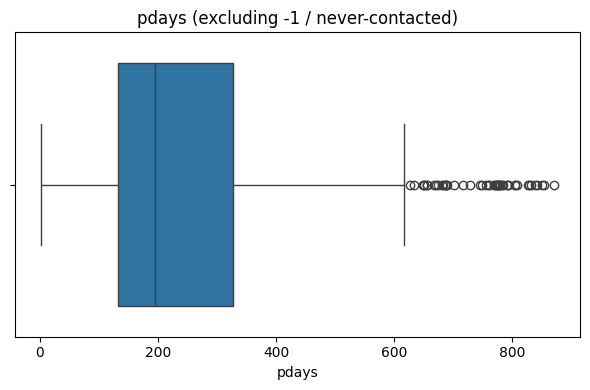

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

continuous_cols = ['age', 'balance', 'duration']
count_cols = ['campaign', 'previous']

# --- Continuous columns: box plots ---
fig, axes = plt.subplots(1, len(continuous_cols), figsize=(5 * len(continuous_cols), 4))
for ax, col in zip(axes, continuous_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# --- Discrete count columns: bar charts of value counts ---
fig, axes = plt.subplots(1, len(count_cols), figsize=(6 * len(count_cols), 4))
for ax, col in zip(axes, count_cols):
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# --- day: bar chart (cyclical / categorical-like, not a good box-plot candidate) ---
fig, ax = plt.subplots(figsize=(10, 4))
df['day'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title('day')
plt.tight_layout()
plt.show()

# --- pdays: sentinel-aware handling ---
# -1 means "never contacted before" -- mixing it into a plain box plot distorts
# the distribution for clients who WERE previously contacted.
was_contacted = df['pdays'] != -1
print(f"Never previously contacted: {(~was_contacted).sum()} ({(~was_contacted).mean():.1%})")

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x=df.loc[was_contacted, 'pdays'], ax=ax)
ax.set_title('pdays (excluding -1 / never-contacted)')
plt.tight_layout()
plt.show()

Transformations to be Applied:
1.Age: Continuous,Log tranformton be applied for outliers, will be done after data split
2.Balance:Continuous,Log tranformto be applied for outliers, will be done after data split
3.Day:Ordinal,No change.
4.Duration:Continuous,Log transform, will be done after data split
5.Campaign:Discrete, create bins.
6.Month:Categorical,One hot encoding, will be done before data split
7.Job:Categorical,One hot encoding, will be done before data split
8.Marital:Categorical,One hot encoding, will be done before data split
9.Education:Categorical,Ordinal encoding, will be done before data split
10.Default:Binary Encoding, will be done before data split
11.housing:Binary Encoding, will be done before data split
12.Loan:Binary Encoding, will be done before data split
13.Contact:Nominal Encoding, will be done before data split
14.y:Binary

Moreover, we had observed spikes in the beginning and end of the month in rate of subscription.This may indicate underlying factors like:

1.More inclined on deposits during the beginning/end of month
2.Usually, people must have recieved salary or are making plans at the beginning of the month.
3.Also possible that highly inclined customers are pursued aggresively by agents at the beginning/end of the month.

## 2. Feature Engineering

Based on the EDA above: bucket `day` into beginning/middle/end-of-month, bucket
`campaign` (contact count) into groups, and prepare the categorical columns for
encoding.

In [24]:
#Add an additional column to indicate if the day falls at the beginning, middle, or end of the month.The beginning is defined as 1 to 3 and the end is defined as 29 to 31. Rest is middle.
#Beginning and end are defined as priority days and rest are non-priority days.

df["day_type"]=df["day"].apply(lambda x: 'P' if 1 <= x <= 3 or 29 <= x <= 31 else 'NP')
day_type_dummies=pd.get_dummies(df["day_type"], prefix="day_type", drop_first=True)
df=pd.concat([df, day_type_dummies], axis=1)
df.drop("day_type", axis=1, inplace=True)




In [25]:
#binning the campaing variable
df['campaign_group'] = pd.cut(df['campaign'],
                               bins=[0, 1, 2, 3, 5, np.inf],
                               labels=['0-1', '1-2', '2-3', '3-5', '>5'],
                               right=True)



In [26]:
campaign_group_dummies = pd.get_dummies(df['campaign_group'], prefix='campaign_group',drop_first=True)
df = pd.concat([df, campaign_group_dummies], axis=1)
df.drop(columns='campaign_group', inplace=True)

Encode the month,job,marital,education and binary encode for default, housing and loan

In [27]:
c1=["job", "marital", "month","poutcome"]
c2=["default", "housing", "loan"]

for i in c1:
    t=pd.get_dummies(df[i], prefix=i, drop_first=True)
    df=pd.concat([df,t], axis=1)
    df.drop(i, axis=1, inplace=True)

for i in c2:
    df[i]=df[i].map({'yes':1,'no':0})



df['education']=df['education'].map({'primary':1,'secondary':2,'tertiary':3,'unknown':0})

contact_dummies = pd.get_dummies(df['contact'], prefix='contact',drop_first=True)
df = pd.concat([df, contact_dummies], axis=1)
df.drop('contact', axis=1, inplace=True)

In [28]:

df.columns

Index(['age', 'education', 'default', 'balance', 'housing', 'loan', 'day',
       'duration', 'campaign', 'pdays', 'previous', 'y', 'day_type_P',
       'campaign_group_1-2', 'campaign_group_2-3', 'campaign_group_3-5',
       'campaign_group_>5', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_married', 'marital_single', 'month_feb',
       'month_mar', 'month_apr', 'month_may', 'month_jun', 'month_jul',
       'month_aug', 'month_sep', 'month_oct', 'month_nov', 'month_dec',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown',
       'contact_telephone', 'contact_unknown'],
      dtype='str')

In [29]:
X = df[[
    'age', 'balance',"default" ,"housing", "loan",

    'day_type_P','pdays', 'previous',

    'campaign_group_1-2', 'campaign_group_2-3',
    'campaign_group_3-5', 'campaign_group_>5',

    'month_apr', 'month_feb', 'month_mar', 'month_may',
    'month_jun', 'month_jul', 'month_aug', 'month_sep',
    'month_oct', 'month_nov', 'month_dec',

    'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
    'job_management', 'job_retired', 'job_self-employed', 'job_services',
    'job_student', 'job_technician', 'job_unemployed', 'job_unknown',

    'marital_married', 'marital_single',

    'education',
    'contact_telephone', 'contact_unknown',
    'poutcome_other', 'poutcome_success', 'poutcome_unknown'
]]

<Axes: ylabel='age'>

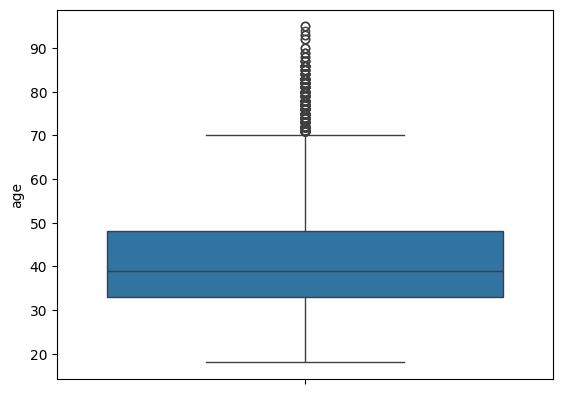

In [30]:
sns.boxplot(df["age"])

In [31]:
Y=df['y']

In [32]:
X.shape, Y.shape

((45211, 42), (45211,))

In [33]:
Y.value_counts(normalize=True)

y
0    0.883015
1    0.116985
Name: proportion, dtype: float64

#Considering the imbalance in the data,so we combine oversampling of minority class and undersampling of majority class to balance out the data.

## 3. Train / Validation / Test Split & Class Imbalance

Since the target is imbalanced (~88% "no" / ~12% "yes"), we combine oversampling of the
minority class with undersampling of the majority class on the **training data only**
(never on validation/test) to give the models a more balanced view during fitting.

We also carve out a **validation set from the training data** (`X_val` / `y_val`),
separate from the training-fit subset (`X_train_fit` / `y_train_fit`) and from the
untouched test set (`X_test` / `y_test`). The reason: later in the notebook we need to
pick a decision threshold for the two-stage pipeline. Picking that threshold by looking
at test-set performance and then reporting test-set performance at that threshold would
be circular — the number would look better than the model will actually perform on
truly new data. The validation set exists so threshold selection and final reporting
never touch the same rows.

In [34]:
from sklearn.model_selection import train_test_split
import random

In [35]:
seed=17
X_train, X_test, y_train, y_test = train_test_split(X, Y, stratify=Y, random_state=seed, test_size=0.2)

In [36]:
# Carve a validation set out of the TRAINING data only. X_test remains fully
# held out until the final "Business results" section below -- any threshold
# we tune is chosen without ever looking at test-set labels.
X_train_fit, X_val, y_train_fit, y_val = train_test_split(
    X_train, y_train, stratify=y_train, random_state=seed, test_size=0.2
)

In [37]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

In [38]:
over = RandomOverSampler(sampling_strategy=0.5, random_state=seed)
under = RandomUnderSampler(sampling_strategy=1.0, random_state=seed)

steps = [('o', over), ('u', under)]
pipeline = Pipeline(steps)
X_resampled, y_resampled = pipeline.fit_resample(X_train, y_train)


**Resampling choice & a calibration caveat.** Oversampling the minority class to a
0.5 ratio and then undersampling the majority class down to 1:1 gives the models a
50/50 view of the classes during training. This tends to help recall on the minority
class, but it also means the raw predicted probabilities coming out of these models
are **not calibrated to the true ~11.7% base rate** — they should be read as relative
scores for ranking/thresholding, not as literal subscription probabilities. This is
why the threshold-tuning step later (rather than a fixed 0.5 cutoff) is important:
it re-calibrates the *decision point* to the actual precision/recall trade-off we
want, even though the underlying probabilities are shifted by the resampling.

In [39]:
y_resampled.value_counts(normalize=True)

y
0    0.5
1    0.5
Name: proportion, dtype: float64

## 4. Rigorous Model Screening (Cross-Validated, Transform-Before-Resample)

For each fold, the Yeo-Johnson transform is
fit on that fold's training data only, then oversampling/undersampling is applied, so no
information from a fold's held-out rows leaks into its training statistics. Candidate
models are ranked by cross-validated **Recall**.

**Why Recall as the primary ranking metric?** In this business context, a missed
subscriber (false negative) is arguably costlier than an unnecessary call (false
positive) — the marginal cost of one extra phone call is small, while a missed sale is
a lost customer entirely. Ranking by Recall at this stage is a deliberate choice to
avoid discarding models that are good at *finding* subscribers just because they also
generate more calls; the precision/call-volume trade-off is then explicitly managed
later via threshold tuning, rather than baked into which algorithm gets picked here.

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    
    AdaBoostClassifier
)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import pandas as pd

X_train['education'] = X_train['education'].fillna(0)

# columns to transform
transform_cols = ['age', 'balance']

preprocessor = ColumnTransformer(
    transformers=[
        (
            'yeojohnson',
            PowerTransformer(method='yeo-johnson'),
            transform_cols
        )
    ],
    remainder='passthrough'
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=seed),
    "RandomForest": RandomForestClassifier(
        n_jobs=-1,
        random_state=seed
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_jobs=-1,
        random_state=seed
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=seed
    ),
    "AdaBoost": AdaBoostClassifier(
        random_state=seed
    ),
    "XGBoost": XGBClassifier(
        n_jobs=-1,
        random_state=seed,
        eval_metric='logloss'
    ),
    "LightGBM": LGBMClassifier(
        n_jobs=-1,
        random_state=seed
    )
}

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('transform', preprocessor),


        ('over', RandomOverSampler(
            sampling_strategy=0.5,
            random_state=seed
        )),

        ('under', RandomUnderSampler(
            sampling_strategy=1.0,
            random_state=seed
        )),

        ('model', model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean()
    })

results_df = pd.DataFrame(results)

print(
    results_df
    .sort_values('Recall', ascending=False)
    .round(4)
)

                Model  Accuracy  Precision  Recall      F1
4            AdaBoost    0.7037     0.2347  0.6722  0.3476
0  LogisticRegression    0.7534     0.2670  0.6332  0.3755
3    GradientBoosting    0.7921     0.3095  0.6287  0.4147
6            LightGBM    0.8109     0.3309  0.6029  0.4273
5             XGBoost    0.8059     0.3161  0.5656  0.4055
1        RandomForest    0.8558     0.3960  0.4417  0.4176
2          ExtraTrees    0.8529     0.3721  0.3746  0.3733


#Pre call modelling using only variables available before the call which are static

`static_data` deliberately excludes anything related to the *current* contact attempt
(channel, month, day, campaign count, previous-campaign outcome) — only attributes a
bank would already know about a client before deciding to call them at all. This is
Stage 1 of the two-stage design.

In [41]:

static_data = [
    'age', 'balance',"default" ,"housing", "loan",

    'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
    'job_management', 'job_retired', 'job_self-employed', 'job_services',
    'job_student', 'job_technician', 'job_unemployed', 'job_unknown',

    'marital_married', 'marital_single',

    'education'
]



X2 = df[static_data]

y2 = df['y']

In [42]:
X2["education"].fillna(0, inplace=True)

C:\Users\PAVILION\AppData\Local\Temp\ipykernel_8376\932740788.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X2["education"].fillna(0, inplace=True)


0        3
1        2
2        2
3        0
4        0
        ..
45206    3
45207    1
45208    2
45209    2
45210    2
Name: education, Length: 45211, dtype: int64

In [43]:
X_stat_train, X_stat_test, y_stat_train, y_stattest = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2   # recommended for classification
)

In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import pandas as pd

# Fill missing values
X_stat_train["education"] = X_stat_train["education"].fillna(0)
X_stat_test["education"] = X_stat_test["education"].fillna(0)

# Columns to transform
transform_cols = ['age', 'balance']

preprocessor = ColumnTransformer(
    transformers=[
        (
            'yeojohnson',
            PowerTransformer(method='yeo-johnson'),
            transform_cols
        )
    ],
    remainder='passthrough'
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        random_state=seed
    ),

    "RandomForest": RandomForestClassifier(
        n_jobs=-1,
        random_state=seed
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_jobs=-1,
        random_state=seed
    ),

    "GradientBoosting": GradientBoostingClassifier(
        random_state=seed
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=seed
    ),

    "XGBoost": XGBClassifier(
        n_jobs=-1,
        random_state=seed,
        eval_metric='logloss'
    ),

    "LightGBM": LGBMClassifier(
        n_jobs=-1,
        random_state=seed,
        verbose=-1
    )
}

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'balanced_accuracy': 'balanced_accuracy'
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('transform', preprocessor),

        ('over', RandomOverSampler(
            sampling_strategy=0.5,
            random_state=seed
        )),

        ('under', RandomUnderSampler(
            sampling_strategy=1.0,
            random_state=seed
        )),

        ('model', model)
    ])

    scores = cross_validate(
        pipeline,
        X_stat_train,
        y_stat_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score='raise'
    )

    results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean(),
        'ROC AUC': scores['test_roc_auc'].mean(),
        'Balanced Accuracy': scores['test_balanced_accuracy'].mean()
    })

results_df = pd.DataFrame(results)

print(
    results_df
    .sort_values('Recall', ascending=False)
    .round(4)
)

                Model  Accuracy  Precision  Recall      F1  ROC AUC  \
4            AdaBoost    0.6465     0.1910  0.6251  0.2925   0.6865   
0  LogisticRegression    0.6329     0.1830  0.6169  0.2822   0.6695   
3    GradientBoosting    0.6859     0.2053  0.5873  0.3043   0.6925   
6            LightGBM    0.7204     0.2215  0.5526  0.3162   0.6962   
5             XGBoost    0.7232     0.2170  0.5238  0.3069   0.6802   
1        RandomForest    0.7987     0.2668  0.4117  0.3237   0.6761   
2          ExtraTrees    0.8033     0.2587  0.3642  0.3024   0.6558   

   Balanced Accuracy  
4             0.6372  
0             0.6260  
3             0.6431  
6             0.6476  
5             0.6367  
1             0.6308  
2             0.6128  


Notice that Adaboost is the best model

**Model-selection note:** both the pre-call model (this section) and the campaign
model (next section) are screened on their *own* train/test splits
(`random_state=42`), separate from the main `X_train`/`X_test` split used everywhere
else (`seed=17`, and the `X_train_fit`/`X_val` split derived from it). This is fine
methodologically — these two splits exist only to pick *which algorithm* to use for
each stage — but it's worth being explicit about, since `clone()` is used later (not
the fitted objects from here) to actually refit on the seed=17 training data. No
fitted state or leakage crosses between these two splits and the final models.

In [45]:
pre_model_1=models["AdaBoost"]

In [46]:
df.columns

Index(['age', 'education', 'default', 'balance', 'housing', 'loan', 'day',
       'duration', 'campaign', 'pdays', 'previous', 'y', 'day_type_P',
       'campaign_group_1-2', 'campaign_group_2-3', 'campaign_group_3-5',
       'campaign_group_>5', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_married', 'marital_single', 'month_feb',
       'month_mar', 'month_apr', 'month_may', 'month_jun', 'month_jul',
       'month_aug', 'month_sep', 'month_oct', 'month_nov', 'month_dec',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown',
       'contact_telephone', 'contact_unknown'],
      dtype='str')

In [47]:
campaign_features = [    'age', 'balance',"default" ,"housing", "loan",

    'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
    'job_management', 'job_retired', 'job_self-employed', 'job_services',
    'job_student', 'job_technician', 'job_unemployed', 'job_unknown',

    'marital_married', 'marital_single',

    'education','day_type_P', 'campaign_group_1-2', 'campaign_group_2-3',
    'campaign_group_3-5', 'campaign_group_>5','month_feb', 'month_mar', 'month_apr', 'month_may', 'month_jun',
    'month_jul', 'month_aug', 'month_sep', 'month_oct', 'month_nov',
    'month_dec','contact_telephone', 'contact_unknown','pdays', 'previous', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']
    

`campaign_features` adds in-campaign context on top of the static features: contact
channel, month, day-of-month bucket, current campaign-contact-count bucket, and the
outcome of any previous campaign. This is Stage 2 — used to refine the score only for
clients Stage 1 already flagged as promising.



In [48]:
X3=df[campaign_features]
X3.head()
y3=df['y']


In [49]:
X_campaign_train, X_campaign_test, y_campaign_train, y_campaign_test = train_test_split(
    X3,
    y3,
    test_size=0.2,
    random_state=42,
    stratify=y3   # recommended for classification
)

In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import pandas as pd

# Fill missing values
X_campaign_train["education"] = X_campaign_train["education"].fillna(0)
X_campaign_test["education"] = X_campaign_test["education"].fillna(0)

# Columns to transform
transform_cols = ['age', 'balance']

preprocessor = ColumnTransformer(
    transformers=[
        (
            'yeojohnson',
            PowerTransformer(method='yeo-johnson'),
            transform_cols
        )
    ],
    remainder='passthrough'
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        random_state=seed
    ),

    "RandomForest": RandomForestClassifier(
        n_jobs=-1,
        random_state=seed
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_jobs=-1,
        random_state=seed
    ),

    "GradientBoosting": GradientBoostingClassifier(
        random_state=seed
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=seed
    ),

    "XGBoost": XGBClassifier(
        n_jobs=-1,
        random_state=seed,
        eval_metric='logloss'
    ),

    "LightGBM": LGBMClassifier(
        n_jobs=-1,
        random_state=seed,
        verbose=-1
    )
}

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'balanced_accuracy': 'balanced_accuracy'
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('transform', preprocessor),

        ('over', RandomOverSampler(
            sampling_strategy=0.5,
            random_state=seed
        )),

        ('under', RandomUnderSampler(
            sampling_strategy=1.0,
            random_state=seed
        )),

        ('model', model)
    ])

    scores = cross_validate(
        pipeline,
        X_campaign_train,
        y_campaign_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score='raise'
    )

    results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean(),
        'ROC AUC': scores['test_roc_auc'].mean(),
        'Balanced Accuracy': scores['test_balanced_accuracy'].mean()
    })

results_df = pd.DataFrame(results)

print(
    results_df
    .sort_values(['F1','ROC AUC'], ascending=False)
    .round(4)
)

                Model  Accuracy  Precision  Recall      F1  ROC AUC  \
6            LightGBM    0.8134     0.3340  0.5975  0.4284   0.7797   
1        RandomForest    0.8570     0.3999  0.4443  0.4210   0.7599   
3    GradientBoosting    0.7959     0.3130  0.6211  0.4161   0.7816   
5             XGBoost    0.8078     0.3170  0.5559  0.4037   0.7569   
2          ExtraTrees    0.8544     0.3771  0.3746  0.3758   0.7345   
0  LogisticRegression    0.7540     0.2666  0.6289  0.3744   0.7650   
4            AdaBoost    0.6899     0.2261  0.6802  0.3393   0.7575   

   Balanced Accuracy  
6             0.7198  
1             0.6780  
3             0.7201  
5             0.6985  
2             0.6463  
0             0.6997  
4             0.6857  


In [51]:
Pre_model_2=models["LightGBM"]



Two stage prediction with Adaboost and Light GBM

`combined_pipeline()` implements the two-stage scoring: Stage 1 (`static_data` →
AdaBoost) produces `stage1_prob`, which is used purely as a **selection/gate** — only
clients above `threshold` proceed to Stage 2 (`campaign_features` → LightGBM). Clients
who don't clear the Stage-1 threshold get a `final_score` of 0 without ever running
Stage 2 — this is what makes the pipeline useful operationally: cheap static features
filter out the bulk of unpromising clients before spending a richer (and more expensive
to act on) campaign-context model on the rest.

**`final_score` is now `stage2_prob` alone**. Since
`campaign_features` is a strict superset of `static_data`, Stage 2 already has access
to everything Stage 1 sees, plus campaign context — so Stage 2's own probability is a
more direct estimate than diluting it with Stage 1's score. Stage 1's role is entirely
about *which clients get scored at all*, not about *how highly a scored client ranks*.

In [ ]:
def combined_pipeline(df, model_1, model_2, precall, beforecall, threshold=0.5):

    df = df.copy()
    df["stage1_prob"] = model_1.predict_proba(df[precall])[:, 1]

    df2 = df[df["stage1_prob"] >= threshold].copy()

    if df2.empty:
        df['stage2_prob'] = 0.0
        df['final_score'] = 0.0
        return df

    df2["stage2_prob"] = model_2.predict_proba(df2[beforecall])[:, 1]
    df2['final_score'] = df2['stage2_prob']

    df = df.merge(df2[['stage2_prob', 'final_score']],
                   left_index=True, right_index=True, how='left')
    df['stage2_prob'] = df['stage2_prob'].fillna(0)
    df['final_score'] = df['final_score'].fillna(0)
    return df

In [53]:
from imblearn.pipeline import Pipeline as ImbPipeline

In [54]:
# columns to transform
transform_cols = ['age', 'balance']

# Resampling-only pipeline (NO transformer here -- transformer is
# handled separately so we can fit on train and only transform on test)
resample_pipeline = ImbPipeline([
    ('over', RandomOverSampler(sampling_strategy=0.5, random_state=seed)),
    ('under', RandomUnderSampler(sampling_strategy=1.0, random_state=seed)),
])


def make_transformer():
    """Returns a fresh ColumnTransformer for age/balance yeo-johnson."""
    return ColumnTransformer(
        transformers=[
            ('yeojohnson', PowerTransformer(method='yeo-johnson'), transform_cols)
        ],
        remainder='passthrough'
    )


def apply_transform(transformer, X, columns, fit=False):
    """
    Apply a ColumnTransformer and return a DataFrame with original 
    column order/names and dtypes preserved.
    NOTE: ColumnTransformer with remainder='passthrough' reorders columns
    (transformed cols first, then passthrough cols), so we rebuild the
    column order explicitly.
    """
    if fit:
        arr = transformer.fit_transform(X)
    else:
        arr = transformer.transform(X)

    passthrough_cols = [c for c in columns if c not in transform_cols]
    new_col_order = transform_cols + passthrough_cols

    out = pd.DataFrame(arr, columns=new_col_order, index=X.index)
    out = out[columns]  # restore original column order
    out = out.astype(X.dtypes.to_dict())
    return out

In [55]:
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
# NOTE: accuracy_score/precision_score/recall_score/f1_score re-imported here since their
# original (only) import lived in the now-removed superseded exploratory-scan section.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

fold_metrics = {
    'Accuracy': [], 'Precision': [], 'Recall': [], 'F1 Score': [], 'ROC AUC': []
}

for fold, (train_idx, test_idx) in enumerate(cv.split(X_train, y_train)):
    X_fold_train, y_fold_train = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_fold_test, y_fold_test = X_train.iloc[test_idx], y_train.iloc[test_idx]

    # 1) Fit transformer on fold-train ONLY, transform fold-train and fold-test
    transformer = make_transformer()
    X_fold_train_t = apply_transform(transformer, X_fold_train, X_fold_train.columns, fit=True)
    X_fold_test_t  = apply_transform(transformer, X_fold_test,  X_fold_test.columns,  fit=False)

    # 2) Resample the (already transformed) training fold
    X_resampled, y_resampled = resample_pipeline.fit_resample(X_fold_train_t, y_fold_train)
    X_resampled = pd.DataFrame(X_resampled, columns=X_fold_train_t.columns)
    y_resampled = pd.Series(y_resampled)
    X_resampled = X_resampled.astype(X_fold_train_t.dtypes.to_dict())

    # 3) Train models on resampled+transformed data
    model_1 = clone(pre_model_1).fit(X_resampled[static_data], y_resampled)
    model_2 = clone(Pre_model_2).fit(X_resampled[campaign_features], y_resampled)

    # 4) Evaluate on transformed fold-test (consistent with training distribution)
    combined_results = combined_pipeline(
        X_fold_test_t,
        model_1,
        model_2,
        precall=static_data,
        beforecall=campaign_features,
        threshold=0.5
    )

    combined_results["y_true"] = y_fold_test.values
    combined_results["y_pred"] = (combined_results["final_score"] >= 0.5).astype(int)

    fold_metrics['Accuracy'].append(accuracy_score(y_fold_test, combined_results['y_pred']))
    fold_metrics['Precision'].append(precision_score(y_fold_test, combined_results['y_pred'], zero_division=0))
    fold_metrics['Recall'].append(recall_score(y_fold_test, combined_results['y_pred'], zero_division=0))
    fold_metrics['F1 Score'].append(f1_score(y_fold_test, combined_results['y_pred'], zero_division=0))
    fold_metrics['ROC AUC'].append(roc_auc_score(y_fold_test, combined_results['final_score']))

In [79]:
avg_result = {metric: np.mean(scores) for metric, scores in fold_metrics.items()}
print("\nAverage Cross-Validation Results (Two-Stage Pipeline):")
for metric, value in avg_result.items():
    print(f"{metric}: {value:.4f}")


Average Cross-Validation Results (Two-Stage Pipeline):
Accuracy: 0.8274
Precision: 0.3371
Recall: 0.4888
F1 Score: 0.3988
ROC AUC: 0.6989


The cross-validation loop above gives an honest, fold-wise estimate of the two-stage
pipeline's performance, since the transformer and resamplers are refit inside each
fold. The next few cells refit everything once on the training data to produce the
actual models used for the validation/test evaluation and the business-impact
analysis.

In [ ]:
# Final model fit (for the held-out X_test evaluation)
# FIX: previously this fit the transformer + resampler + models on the FULL
# X_train, and the decision threshold was then tuned directly on X_test in
# the next cell -- i.e. the threshold was picked using the same rows we then
# reported performance on. Here we fit everything on X_train_fit only (the
# training subset, with X_val carved out above purely for threshold tuning),
# and transform X_val / X_test with that SAME fitted transformer.
# X_test is now touched only once, at the very end, purely for reporting.

final_transformer = make_transformer()
X_train_fit_t = apply_transform(final_transformer, X_train_fit, X_train_fit.columns, fit=True)
X_val_t       = apply_transform(final_transformer, X_val,       X_val.columns,       fit=False)
X_test_t      = apply_transform(final_transformer, X_test,      X_test.columns,      fit=False)

X_train_resampled, y_train_resampled = resample_pipeline.fit_resample(X_train_fit_t, y_train_fit)
X_train_resampled = pd.DataFrame(X_train_resampled, columns=X_train_fit_t.columns)
y_train_resampled = pd.Series(y_train_resampled)
X_train_resampled = X_train_resampled.astype(X_train_fit_t.dtypes.to_dict())


#training the final models on the resampled data
pre_step1A_model = clone(pre_model_1).fit(X_train_resampled[static_data], y_train_resampled)
pre_step1B_model = clone(Pre_model_2).fit(X_train_resampled[campaign_features], y_train_resampled)

In [59]:
# FIX: this threshold grid search now runs on the VALIDATION set
# (X_val_t / y_val), never on X_test. It's an exploratory scan to see the
# trade-off surface; the actual operating threshold used later for reporting
# is chosen via the precision/recall crossover on this same validation set
# (see the "Business results" section below).

X_val_t = X_val_t.fillna(0)

results = []
stage1_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
final_score_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for t1 in stage1_thresholds:
    for t2 in final_score_thresholds:
        df_preds = combined_pipeline(
            X_val_t,
            pre_step1A_model,
            pre_step1B_model,
            precall=static_data,
            beforecall=campaign_features,
            threshold=t1
        )

        df_preds['final_pred'] = (df_preds['final_score'] >= t2).astype(int)

        acc = accuracy_score(y_val, df_preds['final_pred'])
        prec = precision_score(y_val, df_preds['final_pred'], zero_division=0)
        rec = recall_score(y_val, df_preds['final_pred'], zero_division=0)
        f1 = f1_score(y_val, df_preds['final_pred'], zero_division=0)
        roc = roc_auc_score(y_val, df_preds['final_score'])

        results.append({
            'Stage1_Thresh': t1,
            'FinalScore_Thresh': t2,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1 Score': f1,
            'ROC AUC': roc
        })

threshold_df = pd.DataFrame(results).sort_values(by='Recall', ascending=False)
display(threshold_df)

,Stage1_Thresh,FinalScore_Thresh,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,0.1,0.1,0.135748,0.118974,0.997636,0.212594,0.797948
7,0.2,0.1,0.135748,0.118974,0.997636,0.212594,0.797948
14,0.3,0.1,0.138513,0.119202,0.996454,0.212933,0.797994
15,0.3,0.2,0.260575,0.133246,0.966903,0.234216,0.797994
1,0.1,0.2,0.259331,0.133051,0.966903,0.233915,0.797948
8,0.2,0.2,0.259331,0.133051,0.966903,0.233915,0.797948
21,0.4,0.1,0.298175,0.131125,0.888889,0.228537,0.761019
2,0.1,0.3,0.491568,0.173130,0.886525,0.289687,0.797948
9,0.2,0.3,0.491568,0.173130,0.886525,0.289687,0.797948
16,0.3,0.3,0.491982,0.173250,0.886525,0.289855,0.797994


CAMPAIGN SIMULATION

For each test-set client, this generates every combination of contact channel
(`cellular`/`telephone`/`unknown`) and day-of-month bucket (priority vs. non-priority),
holding the client's own static attributes fixed, to see which contact strategy the
model scores most favourably for that client. This is a **what-if simulation**, not a
prediction about what actually happened — it's meant to suggest an outreach strategy,
not to be evaluated against ground truth.

Note the simulation fixes the month to July for every variant (`row_copy['month_jul']
= 1`). That's a deliberate simplification to keep the variant grid small (channel ×
day-type only) rather than exploring month as well — worth calling out explicitly in
any write-up so it doesn't look like an oversight.

In [60]:
import itertools
import pandas as pd

# ------------------------------------------------------------
# Reference categories (dropped during one-hot encoding):
#   contact      -> 'cellular' is the reference (contact_telephone=0, contact_unknown=0)
#   campaign_grp -> '0-1' is the reference (all campaign_group_* dummies = 0)
#   day_type     -> reference category is 0 (day_type_P = 0)
#   month        -> 'jul' is explicitly forced to 1 (kept as in original)
# ------------------------------------------------------------

contact_options = ['cellular', 'telephone', 'unknown']
day_type_p_options = [0, 1]   # day_type_P = 0 or 1



# Define these separately and explicitly
# FIX: 'month_dec' was missing from this list. Since the loop below only zeroes
# out columns in campaign_dummy_cols before forcing month_jul=1, any real
# December contact (month_dec=1) previously kept that flag set -> a simulated
# row with BOTH month_dec=1 and month_jul=1 active, which is not a valid
# one-hot state and would confuse the model. month_dec is now included.
campaign_dummy_cols = [
    'contact_telephone', 'contact_unknown',  # contact dummies
    'day_type_P',                             # day type
    'month_apr', 'month_feb', 'month_mar',   # month dummies
    'month_may', 'month_jun', 'month_jul',
    'month_aug', 'month_sep', 'month_oct', 'month_nov', 'month_dec'
]

def generate_campaign_variants(df_row):
    variants = []
    for contact, day_type_p in itertools.product(contact_options, day_type_p_options):
        row_copy = df_row.copy()

        # zero out ONLY campaign dummies (contact/day-type/month); everything
        # else, including campaign_group_* (contact-history bucket), is left
        # untouched via row_copy = df_row.copy() above
        for feat in campaign_dummy_cols:
            row_copy[feat] = 0

        row_copy['month_jul'] = 1
        if contact != 'cellular':
            row_copy[f'contact_{contact}'] = 1
        row_copy['day_type_P'] = day_type_p

        variants.append(row_copy)

    return pd.DataFrame(variants)

In [61]:
# FIX: build the simulated variants from X_test_t (the Yeo-Johnson-transformed
# version of age/balance), not the raw X_test. The models were trained on
# transformed features, so feeding them raw values here would silently shift
# every prediction in this simulation.
test_variants = pd.concat([generate_campaign_variants(row) for _, row in X_test_t.iterrows()], ignore_index=True)

In [62]:
test_variants.shape

(54258, 42)

In [63]:
df_preds = combined_pipeline(
    test_variants,
    pre_step1A_model,
    pre_step1B_model,
    static_data,
    campaign_features,
)

# Add simulated 'client id' (repeat each index 6 times)
df_preds['client_id'] = np.repeat(X_test_t.index, len(contact_options) * len(day_type_p_options))

In [64]:
top_scenarios = df_preds.groupby('client_id').apply(lambda df: df.loc[df['final_score'].idxmax()]).reset_index()


In [65]:
top_candidates = top_scenarios.sort_values(by='final_score', ascending=False)
top_candidates[['client_id', 'final_score', 'day_type_P', 'contact_telephone', 'contact_unknown' ]].head(30)

,client_id,final_score,day_type_P,contact_telephone,contact_unknown
8647,43146,0.986345,0,1,0
8057,40183,0.974917,0,0,1
8629,43064,0.973425,1,0,0
8917,44542,0.972934,1,1,0
8723,43503,0.972398,0,0,1
8021,40012,0.972171,1,0,1
8958,44763,0.971137,0,1,0
8532,42578,0.971023,1,1,0
8951,44731,0.970350,0,1,0
8621,43014,0.970261,0,1,0


Business results

This section reports the pipeline's real-world impact: how many calls it would save
versus calling every client, how many actual subscribers it would still reach, and how
much agent time it would save — all computed **once**, on the untouched test set, using
the threshold selected on the validation set just above.

In [66]:
# FIX: evaluate on X_test_t (transformed), matching what the models were
# trained on -- previously this passed the raw X_test, which has age/balance
# on a different scale than the model expects.
df_results = combined_pipeline(
            X_test_t,
            pre_step1A_model,
            pre_step1B_model,
            static_data,
            campaign_features,
            threshold=0.5
        )

In [67]:
df_results.shape
X_test.shape

(9043, 42)

In [68]:
df_results['y_true'] = y_test.loc[df_results.index].values

In [69]:
# ------------------------------------------------------------------------
# FIX: the operating threshold below is now selected using a VALIDATION set
# (X_val_t / y_val) that the models never saw during fitting, and which is
# kept separate from the held-out TEST set (X_test_t / y_test / df_results).
# This avoids picking a threshold that happens to look good on the exact
# data we then use to report final performance.
# ------------------------------------------------------------------------
df_results_val = combined_pipeline(
    X_val_t,
    pre_step1A_model,
    pre_step1B_model,
    static_data,
    campaign_features,
    threshold=0.5
)
df_results_val['y_true'] = y_val.loc[df_results_val.index].values

In [70]:
efficiency = {
    'threshold': [],
    'calls_made': [],
    'calls_saved': [],
    'subscribers_reached': [],
    'call_efficiency_1': [],
    'call_efficiency_2': []
}

# NOTE: this efficiency curve is computed on the VALIDATION set
# (df_results_val), purely to choose the precision/recall crossover
# threshold. The final business-impact numbers reported later are computed
# once, on the untouched TEST set, using the threshold picked here.
baseline_calls_val = len(df_results_val)
for threshold in np.arange(0.01, 1.001, 0.01):
    preds = df_results_val['final_score'] > threshold
    y_true = df_results_val['y_true']

    TP = ((preds == True) & (y_true == 1)).sum()
    FP = ((preds == True) & (y_true == 0)).sum()
    FN = ((preds == 0) & (y_true == 1)).sum()

    calls_made = TP + FP
    truth_subscribers = TP + FN
    calls_saved = baseline_calls_val - calls_made
    call_efficiency_1 = TP / calls_made if calls_made else 0  # precision
    call_efficiency_2 = TP / truth_subscribers if truth_subscribers else 0  # recall

    efficiency['threshold'].append(threshold)
    efficiency['calls_made'].append(calls_made)
    efficiency['calls_saved'].append(calls_saved)
    efficiency['subscribers_reached'].append(TP)
    efficiency['call_efficiency_1'].append(call_efficiency_1)
    efficiency['call_efficiency_2'].append(call_efficiency_2)

df_eff = pd.DataFrame(efficiency)

In [83]:
early_df = df_eff.copy()

# Exclude thresholds where the model isn't calling anyone at all -- at that
# point precision and recall both collapse to exactly 0, creating a trivial
# "crossing" that isn't the real precision/recall intersection.
early_df = early_df[early_df['calls_made'] > 0]

early_df['diff_prec_recall'] = (early_df['call_efficiency_2'] - early_df['call_efficiency_1']).abs()
intersection_row = early_df.loc[early_df['diff_prec_recall'].idxmin()]
threshold = intersection_row['threshold']
precision = intersection_row['call_efficiency_1']

In [84]:
# ------------------------------------------------------------------------
# Apply the VALIDATION-selected threshold to the untouched TEST set exactly
# once, to produce the final numbers reported as business impact below.
# ------------------------------------------------------------------------
test_preds = df_results['final_score'] > threshold
test_TP = ((test_preds) & (df_results['y_true'] == 1)).sum()
test_FP = ((test_preds) & (df_results['y_true'] == 0)).sum()
test_FN = ((~test_preds) & (df_results['y_true'] == 1)).sum()

test_calls_made = test_TP + test_FP
test_precision = test_TP / test_calls_made if test_calls_made else 0
test_recall = test_TP / (test_TP + test_FN) if (test_TP + test_FN) else 0

print(f"Threshold selected on validation set: {threshold:.2f}")
print(f"Test-set precision at this threshold: {test_precision:.3f}")
print(f"Test-set recall at this threshold:    {test_recall:.3f}")

Threshold selected on validation set: 0.62
Test-set precision at this threshold: 0.427
Test-set recall at this threshold:    0.421


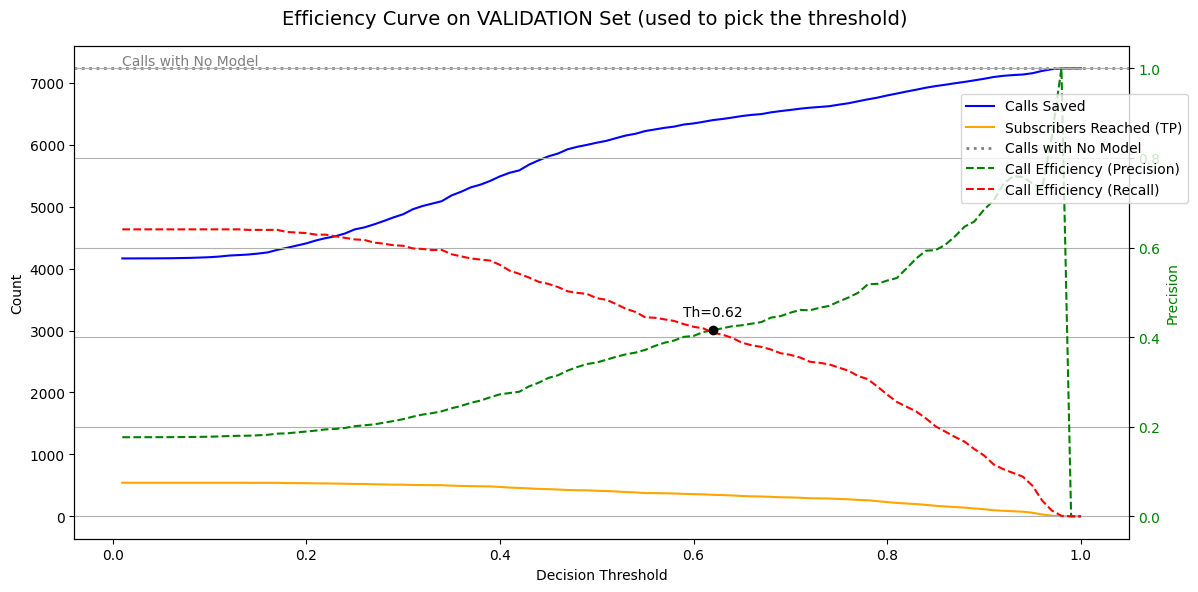

In [85]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# primary Y-axis (Counts)
ax1.plot(df_eff['threshold'], df_eff['calls_saved'], label='Calls Saved', color='blue')
ax1.plot(df_eff['threshold'], df_eff['subscribers_reached'], label='Subscribers Reached (TP)', color='orange')
ax1.set_xlabel('Decision Threshold')
ax1.set_ylabel('Count', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Reference line: total calls with no model, on the VALIDATION set. This
# chart is a diagnostic used only to pick the threshold -- the actual
# TEST-set business numbers are reported in the cells below.
ax1.axhline(y=baseline_calls_val, color='gray', linestyle=':', linewidth=2, label='Calls with No Model')
ax1.text(0.01, baseline_calls_val + 50, 'Calls with No Model', color='gray', fontsize=10)

# secondary Y-axis (Precision)
ax2 = ax1.twinx()
ax2.plot(df_eff['threshold'], df_eff['call_efficiency_1'], label='Call Efficiency (Precision)', color='green', linestyle='--')
ax2.plot(df_eff['threshold'], df_eff['call_efficiency_2'], label='Call Efficiency (Recall)', color='red', linestyle='--')
# Plot intersection point
ax2.plot(threshold, precision, 'ko')  # black dot
ax2.annotate(f'Th={threshold:.2f}', (threshold, precision), textcoords="offset points", xytext=(0,10), ha='center', color='black')
ax2.set_ylabel('Precision', color='green')
ax2.tick_params(axis='y', labelcolor='green')

fig.suptitle('Efficiency Curve on VALIDATION Set (used to pick the threshold)', fontsize=14)
fig.legend(loc="upper right", bbox_to_anchor=(1, 0.85))
fig.tight_layout()
plt.grid(True)
plt.show()

In [86]:
# Final business-impact numbers, computed ONCE on the held-out TEST set,
# using the threshold chosen on the VALIDATION set above (see test_TP /
# test_calls_made computed just before the plot).
baseline_calls = len(df_results)  # all clients in the TEST set, called under the traditional strategy
total_positives = df_results['y_true'].sum()
model_tp = test_TP
model_calls = test_calls_made

ratio_baseline_to_positives = baseline_calls / total_positives
ratio_model_calls_to_tp = model_calls / model_tp

In [87]:
print(f"Baseline strategy (no model): \t\t\t{ratio_baseline_to_positives:.1f} calls per positive subscription")
print(f"Model-based strategy (at threshold={threshold:.2f}):\t{ratio_model_calls_to_tp:.1f} calls per positive subscription")

Baseline strategy (no model): 			8.5 calls per positive subscription
Model-based strategy (at threshold=0.62):	2.3 calls per positive subscription


In [88]:
duration_series = df.loc[X_test.index, 'duration'].copy()
df_results['duration'] = duration_series.values

In [89]:

# Baseline: all clients in test set are called
baseline_total_duration = df_results['duration'].sum()
baseline_total_positives = df_results['y_true'].sum()
baseline_duration_per_subscription = baseline_total_duration / baseline_total_positives

# Model: only predicted positives are called
df_results['predicted_positive'] = df_results['final_score'] > threshold
model_called = df_results[df_results['predicted_positive']]

model_total_duration = model_called['duration'].sum()
model_total_tp = ((model_called['y_true'] == 1)).sum()
model_duration_per_subscription = model_total_duration / model_total_tp

# Print results
print(f"Baseline total duration (all calls): \t{baseline_total_duration:.0f} seconds")
print(f"Baseline duration per subscription: \t{baseline_duration_per_subscription:.1f} seconds")

print(f"Model total duration (calls made): \t{model_total_duration:.0f} seconds")
print(f"Model duration per subscription: \t{model_duration_per_subscription:.1f} seconds")

print(f"Time efficiency improvement: \t\t{baseline_duration_per_subscription / model_duration_per_subscription:.2f}x")

Baseline total duration (all calls): 	2323013 seconds
Baseline duration per subscription: 	2195.7 seconds
Model total duration (calls made): 	294853 seconds
Model duration per subscription: 	662.6 seconds
Time efficiency improvement: 		3.31x
